<a href="https://colab.research.google.com/github/phupha007-1/test/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
# ============================================
# PART 1 : IMPORT LIBRARIES
# ============================================
import random
import sqlite3
from datetime import datetime, timedelta

import pandas as pd
import matplotlib.pyplot as plt

In [46]:
# ============================================
# PART 2 : CLASS MEMBER
# ============================================

class Member:

    def __init__(
        self,
        member_id,
        name,
        age,
        weight_kg,
        is_vip=False
    ):

        self.member_id = member_id
        self.name = name
        self.age = age
        self.weight_kg = weight_kg
        self.is_vip = is_vip


    def get_member_type(self):

        if self.is_vip:
            return "VIP"

        return "General"


    def __str__(self):

        return (
            f"Member ID: {self.member_id} | "
            f"Name: {self.name} | "
            f"Age: {self.age} | "
            f"Weight: {self.weight_kg} kg | "
            f"Type: {self.get_member_type()}"
        )

In [47]:
# ============================================
# PART 3 : CLASS PACKAGE
# ============================================

class Package:

    def __init__(
        self,
        package_id,
        package_name,
        price,
        max_hours,
        duration_days
    ):

        self.package_id = package_id
        self.package_name = package_name
        self.price = price
        self.max_hours = max_hours
        self.duration_days = duration_days


    def get_package_info(self):

        return {
            "package_id": self.package_id,
            "package_name": self.package_name,
            "price": self.price,
            "max_hours": self.max_hours,
            "duration_days": self.duration_days
        }


    def __str__(self):

        return (
            f"Package ID: {self.package_id} | "
            f"Package: {self.package_name} | "
            f"Price: {self.price} บาท | "
            f"Max Hours: {self.max_hours}"
        )

In [48]:
# ============================================
# PART 4 : CLASS MEMBERSHIPPACKAGE (แก้ไข)
# ============================================

class MembershipPackage:

    def __init__(
        self,
        booking_id,
        member,
        package,
        hours,
        service_type,
        booking_date
    ):

        self.booking_id = booking_id
        self.member = member
        self.package = package
        self.hours = hours
        self.service_type = service_type
        self.booking_date = booking_date
        self.status = "Pending"

    def calculate_price(self):
        # คำนวณส่วนลด 10% หากสมาชิกเป็น VIP
        base_price = self.package.price
        if self.member.is_vip:
            return round(base_price * 0.90, 2)
        return round(base_price, 2)

    def mark_done(self):

        self.status = "Completed"

    def __str__(self):

        return (
            f"Booking ID: {self.booking_id} | "
            f"Member: {self.member.name} | "
            f"Package: {self.package.package_name} | "
            f"Service: {self.service_type} | "
            f"Price: {self.calculate_price()} | "
            f"Status: {self.status}"
        )

In [49]:
# ============================================
# PART 5 : GENERATE 300 DATA
# ============================================

first_names = [

    "ธนกฤต",
    "ณัฐวุฒิ",
    "พชร",
    "ภูริณัฐ",
    "กิตติพงศ์",
    "วรากร",
    "ธนภัทร",
    "ภัทรพล",
    "ณัฐพล",
    "ศุภกร",
    "ก้องภพ",
    "ชยพล",
    "รัชชานนท์",
    "ธีรภัทร",
    "ปวริศ",
    "กรวิชญ์",
    "นนทกร",
    "ภาคภูมิ",
    "อัครพล",
    "สิรวิชญ์",

    "พิมพ์ชนก",
    "ชนากานต์",
    "ณิชาภัทร",
    "ศิริพร",
    "กัญญารัตน์",
    "ชลธิชา",
    "ปุณณภา",
    "ธัญชนก",
    "ณัฐธิดา",
    "พิชชาภา",
    "วริศรา",
    "สุภัสสรา",
    "กมลชนก",
    "ปภาวรินทร์",
    "อริสรา",
    "พัชราภา",
    "นภัสสร",
    "ชญานิศ",
    "กุลธิดา",
    "รินรดา"
]


last_names = [

    "ศรีสุวรรณ",
    "วัฒนกุล",
    "เจริญชัย",
    "พัฒนานนท์",
    "วงศ์วัฒนะ",
    "สุวรรณดี",
    "บุญญฤทธิ์",
    "ชัยวัฒน์",
    "รัตนกุล",
    "ศุภกิจ",
    "ธนากุล",
    "วัฒนชัย",
    "เจริญสุข",
    "พงศ์ไพบูลย์",
    "สิริวัฒน์",
    "กิตติธร",
    "อนันต์ชัย",
    "รุ่งเรือง",
    "พัฒนกุล",
    "ศรีวัฒนานนท์"
]


def generate_name():

    return (
        random.choice(first_names)
        + " "
        + random.choice(last_names)
    )


def generate_booking_date():

    start_date = datetime(2026, 1, 1)

    random_days = random.randint(
        0,
        364
    )

    return start_date + timedelta(
        days=random_days
    )


packages = [

    Package(
        1,
        "Basic",
        1200,
        10,
        30
    ),

    Package(
        2,
        "Premium",
        2500,
        20,
        30
    ),

    Package(
        3,
        "VIP",
        5000,
        50,
        60
    )
]


services = [

    "Gym",
    "Personal Training",
    "Group Class"
]


members_300 = []
member_data = {}


for i in range(1, 301):

    member = Member(

        member_id=i,

        name=generate_name(),

        age=random.randint(18, 40),

        weight_kg=round(
            random.uniform(45, 100),
            1
        ),

        is_vip=random.choice(
            [True, False]
        )
    )

    members_300.append(member)

    member_data[i] = member


memberships_300 = []


for i in range(1, 301):

    selected_member = random.choice(
        members_300
    )

    selected_package = random.choice(
        packages
    )

    selected_service = random.choice(
        services
    )

    selected_hours = random.choice(
        [1, 1.5, 2, 2.5, 3]
    )

    membership = MembershipPackage(

        booking_id=i,

        member=selected_member,

        package=selected_package,

        hours=selected_hours,

        service_type=selected_service,

        booking_date=generate_booking_date()
    )

    membership.mark_done()

    memberships_300.append(
        membership
    )


print("สร้างข้อมูลสำเร็จ")
print("Members:", len(members_300))
print("Membership Packages:", len(memberships_300))

สร้างข้อมูลสำเร็จ
Members: 300
Membership Packages: 300


In [50]:
# ============================================
# PART 6 : CREATE DATAFRAME
# ============================================

data = []


for booking in memberships_300:

    data.append({

        "booking_id":
            booking.booking_id,

        "member_id":
            booking.member.member_id,

        "name":
            booking.member.name,

        "age":
            booking.member.age,

        "weight_kg":
            booking.member.weight_kg,

        "is_vip":
            booking.member.is_vip,

        "package_id":
            booking.package.package_id,

        "package_name":
            booking.package.package_name,

        "price":
            booking.calculate_price(),

        "hours":
            booking.hours,

        "service_type":
            booking.service_type,

        "booking_date":
            booking.booking_date.strftime(
                "%Y-%m-%d"
            ),

        "status":
            booking.status
    })


membership_df = pd.DataFrame(data)


print(membership_df.head())

print("\nจำนวนข้อมูล:")
print(len(membership_df))

   booking_id  member_id                 name  age  weight_kg  is_vip  \
0           1        157  วริศรา ศรีวัฒนานนท์   29       82.9   False   
1           2        276       รินรดา วัฒนกุล   31       94.0   False   
2           3        103       ปวริศ เจริญชัย   28       73.6    True   
3           4        119  กุลธิดา พงศ์ไพบูลย์   22       76.4    True   
4           5        178    ภูริณัฐ สิริวัฒน์   28       95.3    True   

   package_id package_name   price  hours       service_type booking_date  \
0           3          VIP  5000.0    2.0                Gym   2026-12-11   
1           3          VIP  5000.0    2.0                Gym   2026-11-01   
2           1        Basic  1080.0    3.0  Personal Training   2026-02-21   
3           2      Premium  2250.0    2.0                Gym   2026-04-12   
4           3          VIP  4500.0    2.5                Gym   2026-03-23   

      status  
0  Completed  
1  Completed  
2  Completed  
3  Completed  
4  Completed  

จำนวนข้

In [51]:
# ============================================
# PART 7 : BUSINESS QUESTIONS - PANDAS
# ============================================

# --------------------------------------------
# คำถามที่ 1
# บริการประเภทใดสร้างรายได้รวมมากที่สุด?
# --------------------------------------------

q1_pandas = (

    membership_df

    .groupby("service_type")

    .agg(
        total_revenue=(
            "price",
            "sum"
        )
    )

    .sort_values(
        "total_revenue",
        ascending=False
    )
)

print("QUESTION 1")
display(q1_pandas)


# --------------------------------------------
# คำถามที่ 2
# แต่ละบริการมีจำนวนการจองและรายได้รวมเท่าไร?
# --------------------------------------------

q2_pandas = (

    membership_df

    .groupby("service_type")

    .agg(

        total_bookings=(
            "booking_id",
            "count"
        ),

        total_revenue=(
            "price",
            "sum"
        )
    )

    .sort_values(
        "total_revenue",
        ascending=False
    )
)

print("QUESTION 2")
display(q2_pandas)


# --------------------------------------------
# คำถามที่ 3
# น้ำหนักเฉลี่ยของสมาชิกแต่ละบริการเท่าไร?
# --------------------------------------------

q3_pandas = (

    membership_df

    .groupby("service_type")

    .agg(
        avg_weight=(
            "weight_kg",
            "mean"
        )
    )

    .sort_values(
        "avg_weight",
        ascending=False
    )
)

print("QUESTION 3")
display(q3_pandas)

QUESTION 1


,total_revenue
service_type,
Personal Training,331370.0
Group Class,262260.0
Gym,251590.0


QUESTION 2


,total_bookings,total_revenue
service_type,,
Personal Training,115,331370.0
Group Class,97,262260.0
Gym,88,251590.0


QUESTION 3


,avg_weight
service_type,
Personal Training,70.892174
Gym,70.136364
Group Class,69.795876


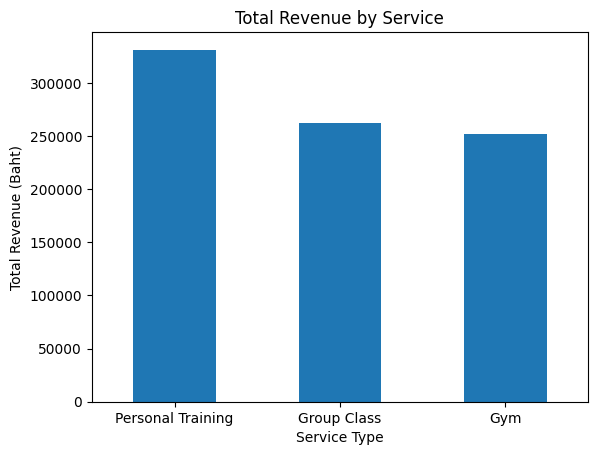

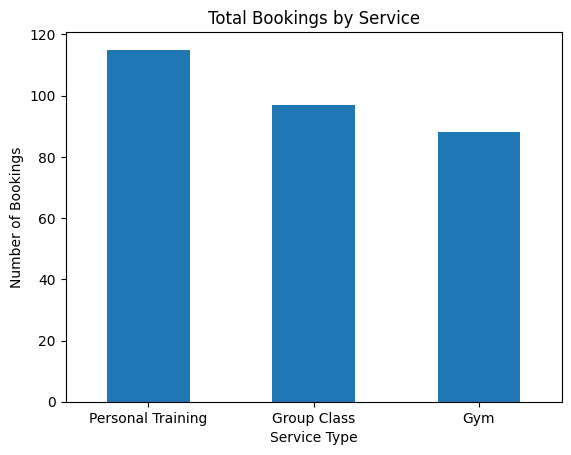

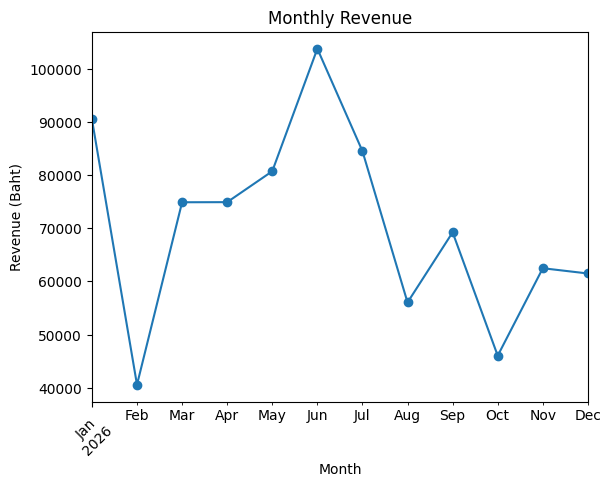

In [52]:
# ============================================
# PART 8 : DATA VISUALIZATION
# ============================================


# --------------------------------------------
# GRAPH 1
# Total Revenue by Service
# --------------------------------------------

q1_pandas.plot(
    kind="bar",
    y="total_revenue",
    legend=False
)

plt.title(
    "Total Revenue by Service"
)

plt.xlabel(
    "Service Type"
)

plt.ylabel(
    "Total Revenue (Baht)"
)

plt.xticks(
    rotation=0
)

plt.show()


# --------------------------------------------
# GRAPH 2
# Total Bookings by Service
# --------------------------------------------

q2_pandas.plot(
    kind="bar",
    y="total_bookings",
    legend=False
)

plt.title(
    "Total Bookings by Service"
)

plt.xlabel(
    "Service Type"
)

plt.ylabel(
    "Number of Bookings"
)

plt.xticks(
    rotation=0
)

plt.show()


# --------------------------------------------
# GRAPH 3
# Monthly Revenue
# --------------------------------------------

membership_df["booking_date"] = pd.to_datetime(
    membership_df["booking_date"]
)


monthly_revenue = (

    membership_df

    .groupby(
        membership_df["booking_date"]
        .dt.to_period("M")
    )

    ["price"]

    .sum()
)


monthly_revenue.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Monthly Revenue"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Revenue (Baht)"
)

plt.xticks(
    rotation=45
)

plt.show()

In [53]:
# ============================================
# PART 9 : EXPORT CSV
# ============================================

membership_df.to_csv(

    "gym_membership_data.csv",

    index=False,

    encoding="utf-8-sig"
)


print(
    "Export CSV สำเร็จ"
)

Export CSV สำเร็จ


In [54]:
# ============================================
# PART 10 : ADD NEW BOOKING (แก้ไขแล้ว)
# ============================================

def add_new_booking():

    global membership_df

    try:

        # 1. เลือก Member
        member_id = int(input("\nกรอก Member ID: "))

        if member_id not in member_data:
            print("❌ ไม่พบ Member ID")
            return

        selected_member = member_data[member_id]

        # 2. ตรวจสอบ VIP
        is_vip_member = bool(selected_member.is_vip)

        # 3. แสดง Package
        print("\n====================================")
        print("             PACKAGE")
        print("====================================")

        for package in packages:
            print(f"{package.package_id} - {package.package_name} - {package.price:,.2f} บาท")

        print("====================================")

        # 4. เลือก Package
        package_id = int(input("กรอก Package ID: "))
        selected_package = find_package(package_id)

        if selected_package is None:
            print("❌ ไม่พบ Package ID")
            return

        # 5. เลือก Service
        print("\n====================================")
        print("           SERVICE TYPE")
        print("====================================")
        print("1. Gym")
        print("2. Personal Training")
        print("3. Group Class")

        service_choice = input("เลือกประเภทบริการ: ").strip()

        if service_choice == "1":
            service_type = "Gym"
        elif service_choice == "2":
            service_type = "Personal Training"
        elif service_choice == "3":
            service_type = "Group Class"
        else:
            print("❌ ประเภทบริการไม่ถูกต้อง")
            return

        # 6. จำนวนชั่วโมง
        hours = float(input("จำนวนชั่วโมง: "))

        if hours <= 0:
            print("❌ จำนวนชั่วโมงต้องมากกว่า 0")
            return

        # 7. วันที่จอง
        booking_date = input("วันที่จอง (YYYY-MM-DD): ").strip()

        # 8. สร้าง Booking ID
        if len(memberships_300) > 0:
            new_booking_id = max(booking.booking_id for booking in memberships_300) + 1
        else:
            new_booking_id = 1

        # 9. สร้าง Booking Object
        new_booking = MembershipPackage(
            booking_id=new_booking_id,
            member=selected_member,
            package=selected_package,
            hours=hours,
            service_type=service_type,
            booking_date=booking_date
        )

        # 10-13. คำนวณส่วนลด
        original_price = float(selected_package.price)
        discount = round(original_price * 0.10, 2) if is_vip_member else 0.0
        final_price = round(original_price - discount, 2)

        # 14. อัปเดตราคาใน Booking
        new_booking.price = final_price

        # 15. แสดงสรุปราคา
        print("\n====================================")
        print("          PRICE SUMMARY")
        print("====================================")
        print(f"ราคาเต็ม       : {original_price:,.2f} บาท")
        print(f"ส่วนลด VIP     : {discount:,.2f} บาท")
        print(f"ราคาสุทธิ      : {final_price:,.2f} บาท")
        print("====================================")

        # 16. เพิ่ม Booking เข้า List
        memberships_300.append(new_booking)

        # 17. สร้าง DataFrame
        new_data = pd.DataFrame([{
            "booking_id": new_booking.booking_id,
            "member_id": selected_member.member_id,
            "name": selected_member.name,
            "age": selected_member.age,
            "weight_kg": selected_member.weight_kg,
            "is_vip": is_vip_member,
            "package_id": selected_package.package_id,
            "package_name": selected_package.package_name,
            "original_price": original_price,
            "discount": discount,
            "price": final_price,
            "hours": new_booking.hours,
            "service_type": new_booking.service_type,
            "booking_date": str(booking_date),
            "status": new_booking.status
        }])

        # 18. เพิ่มลง membership_df
        membership_df = pd.concat([membership_df, new_data], ignore_index=True)

        # 19. บันทึก CSV
        membership_df.to_csv("gym_membership_data.csv", index=False, encoding="utf-8-sig")

        # 20. บันทึก SQLite
        try:

            # แปลงคอลัมน์ booking_date เป็น string ก่อนลง SQL ป้องกัน Error Timestamp
            temp_df = membership_df.copy()
            temp_df["booking_date"] = temp_df["booking_date"].astype(str)

            temp_df.to_sql(
                "gym_memberships",
                conn,
                if_exists="replace",
                index=False
            )
        except Exception as e:
            print(f"⚠️ SQLite ไม่สำเร็จ: {e}")

        # 21. แสดงผล Booking
        print("\n====================================")
        print("        BOOKING SUCCESS")
        print("====================================")
        print(f"Booking ID : {new_booking.booking_id}")
        print(f"Member ID  : {selected_member.member_id}")
        print(f"ชื่อสมาชิก : {selected_member.name}")
        print(f"VIP        : {'ใช่' if is_vip_member else 'ไม่ใช่'}")
        print(f"Package    : {selected_package.package_name}")
        print(f"Service    : {service_type}")
        print(f"ราคาเต็ม   : {original_price:,.2f} บาท")
        print(f"ส่วนลด VIP : {discount:,.2f} บาท")
        print(f"ราคาสุทธิ  : {final_price:,.2f} บาท")
        print(f"วันที่จอง   : {booking_date}")
        print("====================================")

    except ValueError:
        print("❌ กรุณากรอกข้อมูลให้ถูกต้อง")
    except Exception as e:
        print(f"❌ เกิดข้อผิดพลาด: {e}")

In [55]:
# ============================================
# PART 11 : SUMMARY REPORT
# ============================================

total_bookings = len(
    membership_df
)

total_revenue = membership_df[
    "price"
].sum()

average_price = membership_df[
    "price"
].mean()

vip_bookings = membership_df[
    "is_vip"
].sum()


print(
    "================================"
)

print(
    "      GYM MEMBERSHIP REPORT"
)

print(
    "================================"
)

print(
    f"Total Bookings: {total_bookings}"
)

print(
    f"Total Revenue: {total_revenue:,.2f} Baht"
)

print(
    f"Average Price: {average_price:,.2f} Baht"
)

print(
    f"VIP Bookings: {vip_bookings}"
)

print(
    "================================"
)

      GYM MEMBERSHIP REPORT
Total Bookings: 300
Total Revenue: 845,220.00 Baht
Average Price: 2,817.40 Baht
VIP Bookings: 148


In [56]:
# ============================================
# PART 12 : SQLITE DATABASE
# ============================================

conn = sqlite3.connect(
    "fitness_gym.db"
)


membership_df.to_sql(

    "gym_memberships",

    conn,

    if_exists="replace",

    index=False
)


print(
    "บันทึกข้อมูลลง SQLite สำเร็จ"
)

บันทึกข้อมูลลง SQLite สำเร็จ


In [57]:
# ============================================
# PART 13 : SQL ANALYSIS
# ============================================


# --------------------------------------------
# QUESTION 1
# --------------------------------------------

q1_sql = pd.read_sql_query("""

    SELECT

        service_type,

        SUM(price)
        AS total_revenue

    FROM gym_memberships

    GROUP BY service_type

    ORDER BY total_revenue DESC

""", conn)


print(
    "QUESTION 1 - SQL"
)

display(q1_sql)


# --------------------------------------------
# QUESTION 2
# --------------------------------------------

q2_sql = pd.read_sql_query("""

    SELECT

        service_type,

        COUNT(booking_id)
        AS total_bookings,

        SUM(price)
        AS total_revenue

    FROM gym_memberships

    GROUP BY service_type

    ORDER BY total_revenue DESC

""", conn)


print(
    "QUESTION 2 - SQL"
)

display(q2_sql)


# --------------------------------------------
# QUESTION 3
# --------------------------------------------

q3_sql = pd.read_sql_query("""

    SELECT

        service_type,

        AVG(weight_kg)
        AS avg_weight

    FROM gym_memberships

    GROUP BY service_type

    ORDER BY avg_weight DESC

""", conn)


print(
    "QUESTION 3 - SQL"
)

display(q3_sql)

QUESTION 1 - SQL


,service_type,total_revenue
0,Personal Training,331370.0
1,Group Class,262260.0
2,Gym,251590.0


QUESTION 2 - SQL


,service_type,total_bookings,total_revenue
0,Personal Training,115,331370.0
1,Group Class,97,262260.0
2,Gym,88,251590.0


QUESTION 3 - SQL


,service_type,avg_weight
0,Personal Training,70.892174
1,Gym,70.136364
2,Group Class,69.795876


In [58]:
# ============================================
# PART 14 : DATABASE TABLES + JOIN
# ============================================


# --------------------------------------------
# MEMBERS
# --------------------------------------------

members_df = pd.DataFrame([

    {
        "member_id": member.member_id,
        "name": member.name,
        "age": member.age,
        "weight_kg": member.weight_kg,
        "is_vip": int(member.is_vip)
    }

    for member in members_300
])


members_df.to_sql(

    "members",

    conn,

    if_exists="replace",

    index=False
)


# --------------------------------------------
# PACKAGES
# --------------------------------------------

packages_df = pd.DataFrame([

    package.get_package_info()

    for package in packages
])


packages_df.to_sql(

    "packages",

    conn,

    if_exists="replace",

    index=False
)


# --------------------------------------------
# SERVICES
# --------------------------------------------

services_df = pd.DataFrame({

    "service_id": range(
        1,
        len(services) + 1
    ),

    "service_name": services
})


services_df.to_sql(

    "services",

    conn,

    if_exists="replace",

    index=False
)


# --------------------------------------------
# CREATE MEMBERSHIP TABLE
# --------------------------------------------

service_map = {

    service: i + 1

    for i, service in enumerate(
        services
    )
}


bookings_df = membership_df.copy()

bookings_df["service_id"] = (

    bookings_df["service_type"]
    .map(service_map)
)


bookings_df = bookings_df[

    [

        "booking_id",
        "member_id",
        "package_id",
        "service_id",
        "price",
        "hours",
        "booking_date",
        "status"
    ]
]


bookings_df.to_sql(

    "membership_bookings",

    conn,

    if_exists="replace",

    index=False
)


# --------------------------------------------
# JOIN 4 TABLES
# --------------------------------------------

join_result = pd.read_sql_query("""

    SELECT

        b.booking_id,

        m.name
        AS member_name,

        CASE

            WHEN m.is_vip = 1
            THEN 'VIP'

            ELSE 'General'

        END
        AS member_type,

        p.package_name,

        s.service_name,

        b.price,

        b.hours,

        b.booking_date,

        b.status

    FROM membership_bookings b

    JOIN members m

        ON b.member_id = m.member_id

    JOIN packages p

        ON b.package_id = p.package_id

    JOIN services s

        ON b.service_id = s.service_id

    ORDER BY b.booking_id

""", conn)


print(
    "JOIN 4 TABLES สำเร็จ"
)

display(
    join_result.head(10)
)

JOIN 4 TABLES สำเร็จ


,booking_id,member_name,member_type,package_name,service_name,price,hours,booking_date,status
0,1,วริศรา ศรีวัฒนานนท์,General,VIP,Gym,5000.0,2.0,2026-12-11 00:00:00,Completed
1,2,รินรดา วัฒนกุล,General,VIP,Gym,5000.0,2.0,2026-11-01 00:00:00,Completed
2,3,ปวริศ เจริญชัย,VIP,Basic,Personal Training,1080.0,3.0,2026-02-21 00:00:00,Completed
3,4,กุลธิดา พงศ์ไพบูลย์,VIP,Premium,Gym,2250.0,2.0,2026-04-12 00:00:00,Completed
4,5,ภูริณัฐ สิริวัฒน์,VIP,VIP,Gym,4500.0,2.5,2026-03-23 00:00:00,Completed
5,6,ปวริศ เจริญสุข,VIP,Premium,Gym,2250.0,2.5,2026-05-02 00:00:00,Completed
6,7,อัครพล กิตติธร,General,VIP,Group Class,5000.0,1.5,2026-01-16 00:00:00,Completed
7,8,ชนากานต์ ศุภกิจ,VIP,Premium,Personal Training,2250.0,1.0,2026-09-19 00:00:00,Completed
8,9,ธนกฤต รุ่งเรือง,General,Basic,Group Class,1200.0,2.0,2026-01-09 00:00:00,Completed
9,10,ปุณณภา บุญญฤทธิ์,VIP,VIP,Group Class,4500.0,2.0,2026-07-23 00:00:00,Completed


In [59]:
vip_discount_sql = pd.read_sql_query("""

    SELECT

        b.booking_id,

        m.name
        AS member_name,

        CASE

            WHEN m.is_vip = 1
            THEN 'VIP'

            ELSE 'General'

        END
        AS member_type,

        b.price
        AS original_price,

        CASE

            WHEN m.is_vip = 1
            THEN b.price * 0.10

            ELSE 0

        END
        AS discount,

        CASE

            WHEN m.is_vip = 1
            THEN b.price * 0.90

            ELSE b.price

        END
        AS final_price

    FROM membership_bookings b

    JOIN members m

        ON b.member_id = m.member_id

    ORDER BY b.booking_id

""", conn)


display(
    vip_discount_sql.head(10)
)

,booking_id,member_name,member_type,original_price,discount,final_price
0,1,วริศรา ศรีวัฒนานนท์,General,5000.0,0.0,5000.0
1,2,รินรดา วัฒนกุล,General,5000.0,0.0,5000.0
2,3,ปวริศ เจริญชัย,VIP,1080.0,108.0,972.0
3,4,กุลธิดา พงศ์ไพบูลย์,VIP,2250.0,225.0,2025.0
4,5,ภูริณัฐ สิริวัฒน์,VIP,4500.0,450.0,4050.0
5,6,ปวริศ เจริญสุข,VIP,2250.0,225.0,2025.0
6,7,อัครพล กิตติธร,General,5000.0,0.0,5000.0
7,8,ชนากานต์ ศุภกิจ,VIP,2250.0,225.0,2025.0
8,9,ธนกฤต รุ่งเรือง,General,1200.0,0.0,1200.0
9,10,ปุณณภา บุญญฤทธิ์,VIP,4500.0,450.0,4050.0


In [60]:
# ============================================
# PART 16 : ERROR HANDLING
# ============================================

def find_member(member_id):

    try:

        member_id = int(
            member_id
        )

    except ValueError:

        print(
            "Member ID ต้องเป็นตัวเลข"
        )

        return None


    if member_id not in member_data:

        print(
            f"ไม่พบ Member ID: {member_id}"
        )

        return None


    return member_data[
        member_id
    ]


def find_package(package_id):

    try:

        package_id = int(
            package_id
        )

    except ValueError:

        print(
            "Package ID ต้องเป็นตัวเลข"
        )

        return None


    for package in packages:

        if (
            package.package_id
            == package_id
        ):

            return package


    print(
        f"ไม่พบ Package ID: {package_id}"
    )

    return None


def validate_hours(hours):

    try:

        hours = float(
            hours
        )

    except ValueError:

        print(
            "จำนวนชั่วโมงต้องเป็นตัวเลข"
        )

        return False


    if hours <= 0:

        print(
            "จำนวนชั่วโมงต้องมากกว่า 0"
        )

        return False


    if hours > 12:

        print(
            "ไม่สามารถจองเกิน 12 ชั่วโมง"
        )

        return False


    return True


print(
    "===== ERROR HANDLING TEST ====="
)

find_member(999999)

find_package(999999)

validate_hours(-5)

print(
    validate_hours(2)
)

===== ERROR HANDLING TEST =====
ไม่พบ Member ID: 999999
ไม่พบ Package ID: 999999
จำนวนชั่วโมงต้องมากกว่า 0
True


In [61]:
# ============================================
# PART 17 : FITNESS DASHBOARD
# DAILY / WEEKLY / MONTHLY
# ============================================

def dashboard_report(report_type):

    data = membership_df.copy()

    data["booking_date"] = (
        pd.to_datetime(
            data["booking_date"]
        )
    )


    # ========================================
    # DAILY
    # ========================================

    if report_type == "1":

        date_input = input(
            "กรอกวันที่ (YYYY-MM-DD): "
        ).strip()


        try:

            selected_date = (
                pd.to_datetime(
                    date_input,
                    format="%Y-%m-%d"
                )
            )


        except ValueError:

            print(
                "รูปแบบวันที่ไม่ถูกต้อง"
            )

            return


        report = data[

            data["booking_date"].dt.date

            ==

            selected_date.date()
        ]


        title = (
            f"วันที่ {selected_date.date()}"
        )


    # ========================================
    # WEEKLY
    # ========================================

    elif report_type == "2":

        date_input = input(
            "กรอกวันที่ในสัปดาห์ (YYYY-MM-DD): "
        ).strip()


        try:

            selected_date = (
                pd.to_datetime(
                    date_input,
                    format="%Y-%m-%d"
                )
            )


        except ValueError:

            print(
                "รูปแบบวันที่ไม่ถูกต้อง"
            )

            return


        start_date = (

            selected_date

            - pd.Timedelta(
                days=selected_date.weekday()
            )
        )


        end_date = (

            start_date

            + pd.Timedelta(
                days=6
            )
        )


        report = data[

            (
                data["booking_date"]
                >= start_date
            )

            &

            (
                data["booking_date"]
                < end_date
                + pd.Timedelta(days=1)
            )
        ]


        title = (

            f"สัปดาห์ "

            f"{start_date.date()} "

            f"ถึง "

            f"{end_date.date()}"
        )


    # ========================================
    # MONTHLY
    # ========================================

    elif report_type == "3":

        try:

            year = int(
                input("กรอกปี: ")
            )

            month = int(
                input("กรอกเดือน (1-12): ")
            )


        except ValueError:

            print(
                "กรุณากรอกตัวเลข"
            )

            return


        if month < 1 or month > 12:

            print(
                "เดือนไม่ถูกต้อง"
            )

            return


        report = data[

            (
                data["booking_date"].dt.year
                == year
            )

            &

            (
                data["booking_date"].dt.month
                == month
            )
        ]


        title = (
            f"เดือน {month}/{year}"
        )


    else:

        print(
            "กรุณาเลือก 1, 2 หรือ 3"
        )

        return


    # ========================================
    # SUMMARY
    # ========================================

    total_bookings = len(
        report
    )


    total_revenue = report[
        "price"
    ].sum()


    average_revenue = (

        report["price"].mean()

        if total_bookings > 0

        else 0
    )


    vip_count = (

        report["is_vip"].sum()

        if total_bookings > 0

        else 0
    )


    general_count = (

        total_bookings

        - vip_count
    )


    print(
        "\n===================================="
    )

    print(
        "    FITNESS MEMBERSHIP DASHBOARD"
    )

    print(
        "===================================="
    )

    print(
        f"ช่วงเวลา: {title}"
    )

    print(
        f"จำนวนการจอง: {total_bookings}"
    )

    print(
        f"รายได้รวม: {total_revenue:,.2f} บาท"
    )

    print(
        f"รายได้เฉลี่ย: {average_revenue:,.2f} บาท"
    )

    print(
        f"VIP: {vip_count}"
    )

    print(
        f"General: {general_count}"
    )

    print(
        "===================================="
    )


    if total_bookings > 0:

        service_summary = (

            report

            .groupby(
                "service_type"
            )

            .agg(

                bookings=(
                    "booking_id",
                    "count"
                ),

                revenue=(
                    "price",
                    "sum"
                )
            )

            .sort_values(
                "revenue",
                ascending=False
            )
        )


        print(
            "\nSERVICE SUMMARY"
        )

        display(
            service_summary
        )


    else:

        print(
            "\nไม่มีข้อมูลในช่วงเวลาที่เลือก"
        )


# ============================================
# DASHBOARD MENU
# ============================================

def dashboard_menu():

    while True:

        print(
            "\n=============================="
        )

        print(
            "      FITNESS DASHBOARD"
        )

        print(
            "=============================="
        )

        print(
            "1. รายวัน"
        )

        print(
            "2. รายสัปดาห์"
        )

        print(
            "3. รายเดือน"
        )

        print(
            "0. ออกจาก Dashboard"
        )


        choice = input(
            "เลือกช่วงเวลา: "
        ).strip()


        if choice == "0":

            print(
                "ออกจาก Dashboard"
            )

            break


        dashboard_report(
            choice
        )

In [62]:
# ============================================
# VIEW ALL PACKAGES
# ============================================

def view_all_packages():

    print("\n====================================")
    print("          PACKAGE INFORMATION")
    print("====================================")

    print(
        f"{'ID':<5}"
        f"{'Package':<15}"
        f"{'Price':<12}"
        f"{'Max Hours':<12}"
        f"{'Duration':<12}"
    )

    print("-" * 56)

    for package in packages:

        print(
            f"{package.package_id:<5}"
            f"{package.package_name:<15}"
            f"{package.price:,.2f} บาท"
            f"{'':<3}"
            f"{package.max_hours:<12}"
            f"{package.duration_days} days"
        )

    print("====================================")

In [63]:
# ============================================
# SEARCH BOOKING
# ============================================

def search_booking():

    global membership_df

    try:

        booking_id = int(
            input("\nกรอก Booking ID: ")
        )

        result = membership_df[
            membership_df["booking_id"] == booking_id
        ]

        if result.empty:

            print("❌ ไม่พบข้อมูลการจอง")

        else:

            booking = result.iloc[0]

            # คำนวณส่วนลด VIP สำหรับแสดงผล
            for p in packages:
                if p.package_id == booking['package_id']:
                    original_price = float(p.price)
                    break

            is_vip_bool = bool(booking['is_vip'])
            discount = original_price * 0.10 if is_vip_bool else 0.0
            final_price = original_price - discount

            print("\n====================================")
            print("          BOOKING INFORMATION")
            print("====================================")

            print(f"Booking ID   : {booking['booking_id']}")
            print(f"Member ID    : {booking['member_id']}")
            print(f"ชื่อสมาชิก   : {booking['name']}")
            print(f"อายุ         : {booking['age']} ปี")
            print(f"น้ำหนัก      : {booking['weight_kg']} kg")
            print(f"VIP          : {'ใช่' if is_vip_bool else 'ไม่ใช่'}")

            print("------------------------------------")

            print(f"Package ID   : {booking['package_id']}")
            print(f"Package      : {booking['package_name']}")
            print(f"Service      : {booking['service_type']}")
            print(f"จำนวนชั่วโมง : {booking['hours']} ชั่วโมง")

            print("------------------------------------")

            print(f"ราคาเต็ม     : {original_price:,.2f} บาท")
            print(f"ส่วนลด VIP   : {discount:,.2f} บาท")
            print(f"ราคาสุทธิ    : {final_price:,.2f} บาท")
            print(f"วันที่จอง    : {booking['booking_date']}")
            print(f"สถานะ        : {booking['status']}")

            print("====================================")


    except ValueError:

        print("❌ Booking ID ต้องเป็นตัวเลข")

In [64]:
# ============================================
# SAVE DATA
# ============================================

def save_data():

    global membership_df

    # ----------------------------------------
    # SAVE CSV
    # ----------------------------------------

    membership_df.to_csv(

        "gym_membership_data.csv",

        index=False,

        encoding="utf-8-sig"
    )


    # ----------------------------------------
    # SAVE SQLITE
    # ----------------------------------------

    membership_df.to_sql(

        "gym_memberships",

        conn,

        if_exists="replace",

        index=False
    )


In [65]:
# ============================================
# MAIN MENU
# ============================================

def main_menu():

    while True:

        print("\n====================================")
        print("          FITNESS GYM SYSTEM")
        print("====================================")

        print("1. สมัครสมาชิก")
        print("2. ใช้บริการ / จอง Package")
        print("3. ดู Package ทั้งหมด")
        print("4. ค้นหาข้อมูลการจอง")
        print("5. Service & Revenue Dashboard")
        print("6. ออกจากระบบ")

        print("====================================")


        choice = input(
            "เลือกเมนู: "
        ).strip()


        # ====================================
        # 1. ADD MEMBER
        # ====================================

        if choice == "1":

            try:

                name = input(
                    "ชื่อสมาชิก: "
                ).strip()


                age = int(
                    input("อายุ: ")
                )


                weight = float(
                    input("น้ำหนัก (kg): ")
                )


                vip_input = input(
                    "สมัครเป็นสมาชิก VIP หรือไม่? (สมัคร/ไม่สมัคร): "
                ).strip().lower()


                is_vip = (
                    vip_input == "สมัคร"
                )


                new_member_id = (
                    max(member_data.keys()) + 1
                )


                new_member = Member(

                    new_member_id,

                    name,

                    age,

                    weight,

                    is_vip
                )


                members_300.append(
                    new_member
                )


                member_data[
                    new_member_id
                ] = new_member


                print("\n================================")
                print("       สมัครสมาชิกสำเร็จ!")
                print("================================")

                print(new_member)


            except ValueError:

                print(
                    "❌ กรุณากรอกข้อมูลให้ถูกต้อง"
                )


        # ====================================
        # 2. BOOK PACKAGE
        # ====================================

        elif choice == "2":

            add_new_booking()


        # ====================================
        # 3. VIEW PACKAGES
        # ====================================

        elif choice == "3":

            view_all_packages()


        # ====================================
        # 4. SEARCH BOOKING
        # ====================================

        elif choice == "4":

            search_booking()


        # ====================================
        # 5. REPORT DASHBOARD
        # ====================================

        elif choice == "5":

            dashboard_menu()


        # ====================================
        # 6. EXIT
        # ====================================

        elif choice == "6":

            print("\nขอบคุณที่ใช้ FITNESS GYM SYSTEM")
            print("ออกจากระบบเรียบร้อย 👋")

            break


        # ====================================
        # INVALID
        # ====================================

        else:

            print(
                "❌ กรุณาเลือกเมนู 1-6"
            )

In [ ]:
main_menu()


          FITNESS GYM SYSTEM
1. สมัครสมาชิก
2. ใช้บริการ / จอง Package
3. ดู Package ทั้งหมด
4. ค้นหาข้อมูลการจอง
5. Service & Revenue Dashboard
6. ออกจากระบบ
เลือกเมนู: 1
ชื่อสมาชิก: ภูผา บุญเคน
อายุ: 20
น้ำหนัก (kg): 70
สมัครเป็นสมาชิก VIP หรือไม่? (สมัคร/ไม่สมัคร): สมัคร

       สมัครสมาชิกสำเร็จ!
Member ID: 301 | Name: ภูผา บุญเคน | Age: 20 | Weight: 70.0 kg | Type: VIP

          FITNESS GYM SYSTEM
1. สมัครสมาชิก
2. ใช้บริการ / จอง Package
3. ดู Package ทั้งหมด
4. ค้นหาข้อมูลการจอง
5. Service & Revenue Dashboard
6. ออกจากระบบ
เลือกเมนู: 2

กรอก Member ID: 301

             PACKAGE
1 - Basic - 1,200.00 บาท
2 - Premium - 2,500.00 บาท
3 - VIP - 5,000.00 บาท
กรอก Package ID: 1

           SERVICE TYPE
1. Gym
2. Personal Training
3. Group Class
เลือกประเภทบริการ: 1
จำนวนชั่วโมง: 3
วันที่จอง (YYYY-MM-DD): 2026-08-23

          PRICE SUMMARY
ราคาเต็ม       : 1,200.00 บาท
ส่วนลด VIP     : 120.00 บาท
ราคาสุทธิ      : 1,080.00 บาท

        BOOKING SUCCESS
Booking ID : 301
Member ID  : 301


,bookings,revenue
service_type,,
Personal Training,8,24680.0
Group Class,3,9250.0
Gym,4,6660.0



      FITNESS DASHBOARD
1. รายวัน
2. รายสัปดาห์
3. รายเดือน
0. ออกจาก Dashboard
